In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
from sklearn.model_selection import train_test_split

In [2]:
# -----------------------
# GPU : memoria growth (recomendado)
# -----------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print("GPUs:", gpus)
    except Exception as e:
        print("GPU config error:", e)

# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# --- Hiperparámetros del Dataset y Modelo ---
DATA_DIR = 'datasets/plates_mask_crops_comb' # ¡IMPORTANTE: Cambia esta ruta!
IMG_HEIGHT = 200  # Altura a la que se redimensionarán las imágenes
IMG_WIDTH = 400   # Ancho. Proporción 2:1 es común para placas
BATCH_SIZE = 64

# --- 1. Encontrar y emparejar las imágenes y máscaras ---
def get_image_paths(data_dir):
    image_paths = []
    mask_paths = []
    for filename in sorted(os.listdir(data_dir)):
        lower = filename.lower()
        # Buscar solo archivos de imagen que sean JPG/JPEG (no máscaras)
        if lower.endswith(('.jpg', '.jpeg')):
            base, _ = os.path.splitext(filename)
            # Evitar archivos que por alguna razón ya sean máscaras (ej. name_mask.jpg)
            if base.endswith('_mask'):
                continue

            img_path = os.path.join(data_dir, filename)
            mask_path = os.path.join(data_dir, f"{base}_mask.png")

            # Asegurarse de que la máscara exista
            if os.path.exists(mask_path):
                image_paths.append(img_path)
                mask_paths.append(mask_path)

    return image_paths, mask_paths


all_image_paths, all_mask_paths = get_image_paths(DATA_DIR)
print(f"Se encontraron {len(all_image_paths)} pares de imagen/máscara.")

# --- 2. Dividir en conjuntos de entrenamiento y validación ---
train_img_paths, val_img_paths, train_mask_paths, val_mask_paths = train_test_split(
    all_image_paths, all_mask_paths, test_size=0.2, random_state=42
)
print(f"Muestras de entrenamiento: {len(train_img_paths)}, Muestras de validación: {len(val_img_paths)}")

# --- 3. Crear el pipeline de tf.data ---
def load_and_preprocess(image_path, mask_path):
    # Cargar imagen
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3) # Suponiendo que son a color
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0  # Normalizar a [0, 1]

    # Cargar máscara
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1) # Las máscaras son en escala de grises
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH])
    # Asegurar que la máscara sea binaria (0 o 1) y normalizar
    mask = tf.cast(mask > 128, tf.float32) # Píxeles > 128 serán 1 (blanco), el resto 0 (negro)
    
    return image, mask

def create_dataset(images, masks, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((images, masks))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_dataset = create_dataset(train_img_paths, train_mask_paths)
validation_dataset = create_dataset(val_img_paths, val_mask_paths, shuffle=False)

print("\nDatasets creados exitosamente. ✅")

Se encontraron 4000 pares de imagen/máscara.
Muestras de entrenamiento: 3200, Muestras de validación: 800

Datasets creados exitosamente. ✅


In [4]:
def build_unet_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = layers.Input(input_shape)

    # --- Encoder (Ruta de Contracción) ---
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # --- Cuello de Botella ---
    b = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    b = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(b)

    # --- Decoder (Ruta de Expansión) ---
    u3 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(b)
    u3 = layers.concatenate([u3, c3]) # Skip connection
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u3)
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c6)

    u2 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
    u2 = layers.concatenate([u2, c2]) # Skip connection
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u2)
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c7)

    u1 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c7)
    u1 = layers.concatenate([u1, c1]) # Skip connection
    c8 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u1)
    c8 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c8)

    # --- Capa de Salida ---
    # 1 filtro para la máscara binaria y activación sigmoid para probabilidades [0, 1]
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c8)

    model = keras.Model(inputs=[inputs], outputs=[outputs])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy', # Pérdida ideal para segmentación binaria
        metrics=['accuracy'] # Puedes añadir IoU si lo deseas
    )
    
    return model

model = build_unet_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 200, 400, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 200, 400, 16  448         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 200, 400, 16  2320        ['conv2d[0][0]']                 
                                )                                                             

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

EPOCHS = 30 # Puedes empezar con 30 y ajustar según sea necesario
CHECKPOINT_FILEPATH = 'best_unet_mask_model_5.keras'

# Callback para guardar solo el mejor modelo
checkpoint_callback = ModelCheckpoint(
    filepath=CHECKPOINT_FILEPATH,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

print(f"\n--- Iniciando entrenamiento por {EPOCHS} épocas ---")
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    callbacks=[checkpoint_callback]
)


--- Iniciando entrenamiento por 30 épocas ---
Epoch 1/30
50/50 [==============================] - ETA: 0s - loss: 0.0558 - accuracy: 0.9767
Epoch 1: val_loss improved from inf to 0.07011, saving model to best_unet_mask_model_5.keras
50/50 [==============================] - 25s 477ms/step - loss: 0.0558 - accuracy: 0.9767 - val_loss: 0.0701 - val_accuracy: 0.9724
Epoch 2/30
50/50 [==============================] - ETA: 0s - loss: 0.0556 - accuracy: 0.9768
Epoch 2: val_loss improved from 0.07011 to 0.06476, saving model to best_unet_mask_model_5.keras
50/50 [==============================] - 24s 466ms/step - loss: 0.0556 - accuracy: 0.9768 - val_loss: 0.0648 - val_accuracy: 0.9739
Epoch 3/30
50/50 [==============================] - ETA: 0s - loss: 0.0533 - accuracy: 0.9778
Epoch 3: val_loss did not improve from 0.06476
50/50 [==============================] - 24s 465ms/step - loss: 0.0533 - accuracy: 0.9778 - val_loss: 0.0674 - val_accuracy: 0.9727
Epoch 4/30
50/50 [====================

Cargando el mejor modelo desde: best_unet_mask_model_5.keras
Tomando muestra del dataset de validación...
Realizando predicción...
IoU Score: 0.9841
Dice Score: 0.9920


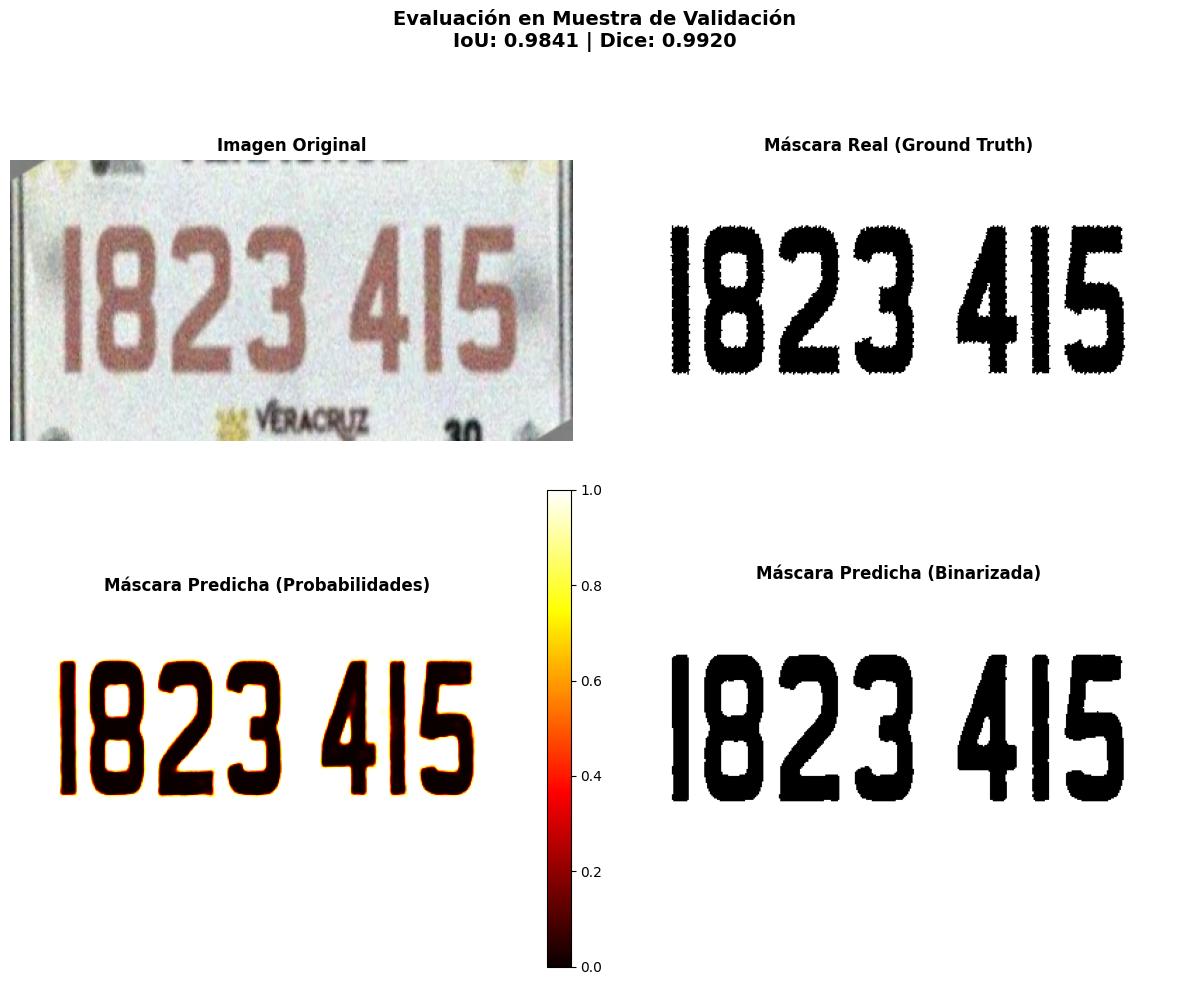

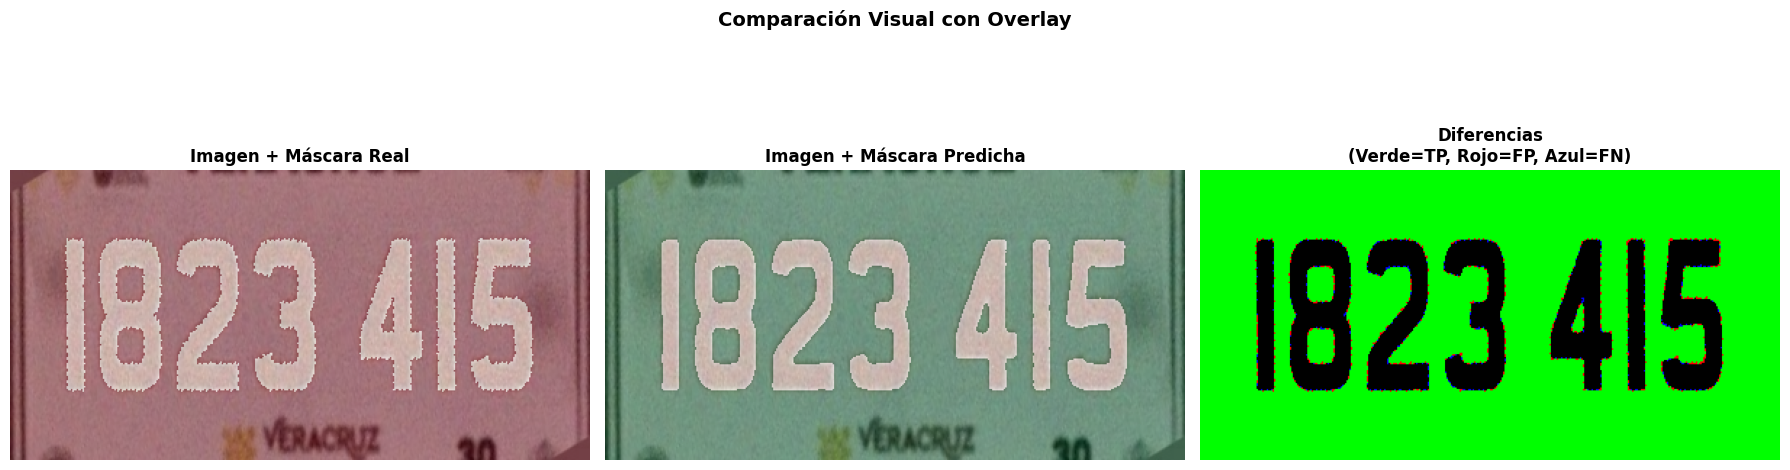


✓ Visualización completada!
  - Verde (True Positives): Predicción correcta de la clase positiva
  - Rojo (False Positives): Predicción incorrecta como positiva
  - Azul (False Negatives): No detectó lo que debería


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Cargar el mejor modelo guardado ---
print(f"Cargando el mejor modelo desde: {CHECKPOINT_FILEPATH}")
best_model = keras.models.load_model(CHECKPOINT_FILEPATH)

# --- 2. Tomar una muestra aleatoria del dataset de validación ---
print("Tomando muestra del dataset de validación...")
image_batch, mask_batch = next(iter(validation_dataset))
random_index = np.random.randint(0, image_batch.shape[0])

sample_image = image_batch[random_index].numpy()
true_mask = mask_batch[random_index].numpy()

# --- 3. Realizar la predicción ---
print("Realizando predicción...")
# El modelo espera un batch, así que añadimos una dimensión
input_image = np.expand_dims(sample_image, axis=0)
predicted_mask = best_model.predict(input_image, verbose=0)[0]

# Binarizar la predicción (valores > 0.5 se convierten en 1, el resto en 0)
predicted_mask_binary = (predicted_mask > 0.5).astype(np.float32)

# --- 4. Calcular métricas para esta predicción ---
# Asegurar que las máscaras tengan la misma forma
true_mask_flat = true_mask.flatten()
pred_mask_flat = predicted_mask_binary.flatten()

# Calcular IoU
intersection = np.sum(true_mask_flat * pred_mask_flat)
union = np.sum(true_mask_flat) + np.sum(pred_mask_flat) - intersection
iou_score = (intersection + 1e-6) / (union + 1e-6)

# Calcular Dice
dice_score = (2.0 * intersection + 1e-6) / (np.sum(true_mask_flat) + np.sum(pred_mask_flat) + 1e-6)

print(f"IoU Score: {iou_score:.4f}")
print(f"Dice Score: {dice_score:.4f}")

# --- 5. Visualizar los resultados ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Evaluación en Muestra de Validación\nIoU: {iou_score:.4f} | Dice: {dice_score:.4f}', 
             fontsize=14, fontweight='bold')

# Imagen original
axes[0, 0].imshow(sample_image)
axes[0, 0].set_title('Imagen Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Máscara real
axes[0, 1].imshow(true_mask.squeeze(), cmap='gray')
axes[0, 1].set_title('Máscara Real (Ground Truth)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Máscara predicha (continua)
im = axes[1, 0].imshow(predicted_mask.squeeze(), cmap='hot', vmin=0, vmax=1)
axes[1, 0].set_title('Máscara Predicha (Probabilidades)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Máscara predicha (binarizada)
axes[1, 1].imshow(predicted_mask_binary.squeeze(), cmap='gray')
axes[1, 1].set_title('Máscara Predicha (Binarizada)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# --- 6. Visualización de comparación lado a lado (overlay) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación Visual con Overlay', fontsize=14, fontweight='bold')

# Imagen con máscara real
axes[0].imshow(sample_image)
axes[0].imshow(true_mask.squeeze(), cmap='Reds', alpha=0.5)
axes[0].set_title('Imagen + Máscara Real', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Imagen con máscara predicha
axes[1].imshow(sample_image)
axes[1].imshow(predicted_mask_binary.squeeze(), cmap='Greens', alpha=0.5)
axes[1].set_title('Imagen + Máscara Predicha', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Comparación de diferencias
# Rojo = False Positive, Verde = True Positive, Azul = False Negative
difference = np.zeros((*true_mask.squeeze().shape, 3))
true_mask_2d = true_mask.squeeze()
pred_mask_2d = predicted_mask_binary.squeeze()

# True Positives (verde)
difference[..., 1] = (true_mask_2d == 1) & (pred_mask_2d == 1)
# False Positives (rojo)
difference[..., 0] = (true_mask_2d == 0) & (pred_mask_2d == 1)
# False Negatives (azul)
difference[..., 2] = (true_mask_2d == 1) & (pred_mask_2d == 0)

axes[2].imshow(difference)
axes[2].set_title('Diferencias\n(Verde=TP, Rojo=FP, Azul=FN)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Visualización completada!")
print(f"  - Verde (True Positives): Predicción correcta de la clase positiva")
print(f"  - Rojo (False Positives): Predicción incorrecta como positiva")
print(f"  - Azul (False Negatives): No detectó lo que debería")

1/1 [==============================] - 0s 19ms/step


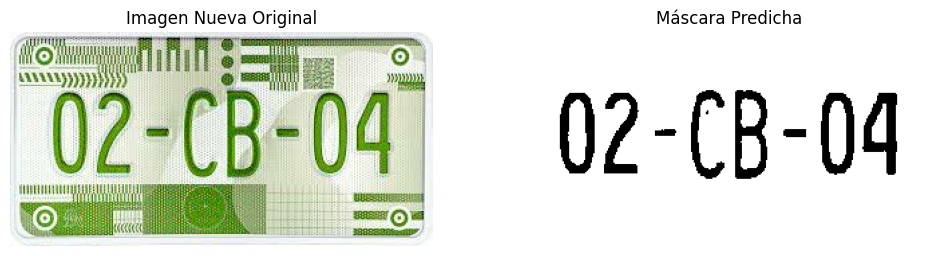

In [7]:
def predict_new_image(image_path, model):
    # Cargar y preprocesar la imagen nueva
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    original_image = tf.identity(image) # Guardar la original para mostrarla
    
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0
    
    # Añadir dimensión de batch y predecir
    input_image = tf.expand_dims(image, axis=0)
    predicted_mask = model.predict(input_image)[0]
    
    # Binarizar y redimensionar la máscara al tamaño original
    predicted_mask = (predicted_mask > 0.5).astype(np.uint8)
    predicted_mask_resized = tf.image.resize(
        predicted_mask, 
        [original_image.shape[0], original_image.shape[1]],
        method='nearest' # 'nearest' para evitar valores intermedios en la máscara
    )
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(original_image)
    axes[0].set_title('Imagen Nueva Original')
    axes[0].axis('off')

    axes[1].imshow(predicted_mask_resized, cmap='gray')
    axes[1].set_title('Máscara Predicha')
    axes[1].axis('off')
    
    plt.show()

# --- EJECUCIÓN ---
# ¡IMPORTANTE: Cambia esta ruta a una imagen de prueba!
new_image_path = 'datasets/eval_final/02-CB-04.jpg' 
if os.path.exists(new_image_path):
    predict_new_image(new_image_path, best_model)
else:
    print(f"Archivo de prueba no encontrado en: {new_image_path}")

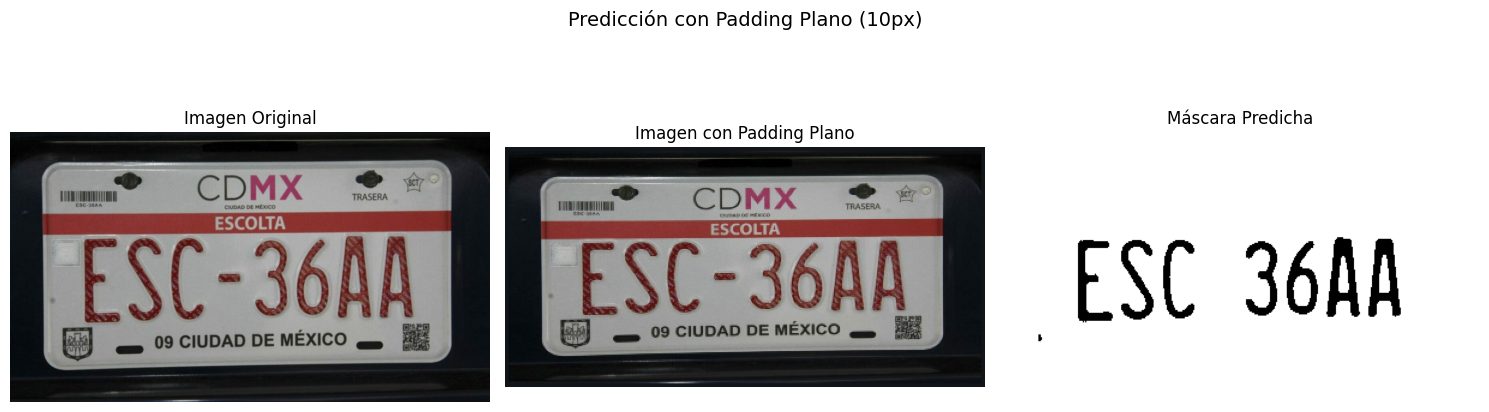

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

def predict_new_image(image_path, model, pad_pixels=20, use_mean_border=True):
    """
    Carga una imagen, le aplica un padding plano (color uniforme tomado del borde),
    luego predice la máscara con el modelo y muestra el resultado.
    """
    # --- Cargar imagen ---
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.cast(image, tf.float32)
    original_image = tf.identity(image)  # Guardar copia para visualización

    # --- Calcular color del borde ---
    if use_mean_border:
        # Usa el color promedio de todos los bordes
        top = image[0, :, :]
        bottom = image[-1, :, :]
        left = image[:, 0, :]
        right = image[:, -1, :]
        border_pixels = tf.concat([top, bottom, left, right], axis=0)
        border_color = tf.reduce_mean(border_pixels, axis=0)
    else:
        # Usa el color del píxel superior izquierdo
        border_color = image[0, 0, :]

    # --- Crear padding de color uniforme ---
    pad_top = tf.ones((pad_pixels, tf.shape(image)[1], 3)) * border_color
    pad_bottom = tf.ones((pad_pixels, tf.shape(image)[1], 3)) * border_color
    padded = tf.concat([pad_top, image, pad_bottom], axis=0)

    pad_left = tf.ones((tf.shape(padded)[0], pad_pixels, 3)) * border_color
    pad_right = tf.ones((tf.shape(padded)[0], pad_pixels, 3)) * border_color
    image_padded = tf.concat([pad_left, padded, pad_right], axis=1)

    # --- Preprocesamiento ---
    image_padded = tf.image.resize(image_padded, [IMG_HEIGHT, IMG_WIDTH])
    image_padded = image_padded / 255.0

    # --- Predicción ---
    input_image = tf.expand_dims(image_padded, axis=0)
    predicted_mask = model.predict(input_image, verbose=0)[0]

    # --- Binarización ---
    predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

    # --- Redimensionar máscara al tamaño original ---
    predicted_mask_resized = tf.image.resize(
        predicted_mask,
        [original_image.shape[0], original_image.shape[1]],
        method='nearest'
    )

    # --- Visualización ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Predicción con Padding Plano ({pad_pixels}px)', fontsize=14)

    axes[0].imshow(tf.cast(original_image / 255.0, tf.float32))
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')

    axes[1].imshow(tf.cast(image_padded, tf.float32))
    axes[1].set_title('Imagen con Padding Plano')
    axes[1].axis('off')

    axes[2].imshow(predicted_mask_resized, cmap='gray')
    axes[2].set_title('Máscara Predicha')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# --- EJEMPLO DE USO ---
new_image_path = 'datasets/eval_final/ESC-36AA.jpg'
if os.path.exists(new_image_path):
    predict_new_image(new_image_path, best_model, pad_pixels=10, use_mean_border=True)
else:
    print(f"Archivo de prueba no encontrado en: {new_image_path}")
